In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
# read in model data for each station
station_names = ["SAR003", "PSS019", "SKG003","HCB004", "HCB003", "ADM003", "CMB003", "GOR001", "CSE001", "EAP001", "SIN001", "PSB003"]

data_lo = {}
data_ssc = {}

for station in station_names:
    filename_lo = f"{station}_2014.01.01_2014.12.31.nc"
    filename_ssc = f"{station}_2014.01.01_2014.12.31_ssc.nc"
    filepath_lo = "./stations/" + filename_lo
    filepath_ssc = "./stations/" + filename_ssc

    data_lo[station] = xr.open_dataset(filepath_lo)
    data_ssc[station] = xr.open_dataset(filepath_ssc)

In [3]:
# read in observational data for each station
data_obs = pd.read_pickle("./combined_bottle_2014_cas7_t1_x11ab_ssc.pkl")
data_obs = data_obs["obs"]

# ensure datatime format 
data_obs["time"] = pd.to_datetime(data_obs["time"])


In [4]:
station = "SAR003"

# print(data_lo[station])
#print(data_ssc[station])

#print(data_lo[station].data_vars)
print(data_ssc[station].data_vars)
print(data_obs.columns)

Data variables:
    PAR                           (time_counter, deptht) float32 58kB ...
    turbidity                     (time_counter, deptht) float32 58kB ...
    dissolved_inorganic_carbon    (time_counter, deptht) float32 58kB ...
    total_alkalinity              (time_counter, deptht) float32 58kB ...
    dissolved_oxygen              (time_counter, deptht) float32 58kB ...
    votemper                      (time_counter, deptht) float32 58kB ...
    vosaline                      (time_counter, deptht) float32 58kB ...
    sigma_theta                   (time_counter, deptht) float32 58kB ...
    e3t                           (time_counter, deptht) float32 58kB ...
    nitrate                       (time_counter, deptht) float32 58kB ...
    ammonium                      (time_counter, deptht) float32 58kB ...
    silicon                       (time_counter, deptht) float32 58kB ...
    diatoms                       (time_counter, deptht) float32 58kB ...
    flagellates       

In [9]:
# print(ds_lo["z_rho"])
print(ds_ssc["deptht"])
# print(np.mean(ds_ssc["deptht"]))

<xarray.DataArray 'deptht' (deptht: 40)> Size: 320B
array([  0.5     ,   1.500003,   2.500012,   3.500031,   4.50007 ,   5.500151,
         6.50031 ,   7.500623,   8.501236,   9.502433,  10.504765,  11.509311,
        12.518167,  13.535412,  14.568982,  15.634287,  16.761173,  18.007135,
        19.481785,  21.389979,  24.100257,  28.229915,  34.685758,  44.517725,
        58.484334,  76.585584,  98.062959, 121.866518, 147.089458, 173.114482,
       199.573049, 226.260306, 253.066637, 279.93455 , 306.834197, 333.75017 ,
       360.674532, 387.603203, 414.534088, 441.46611 ])
Coordinates:
  * deptht   (deptht) float64 320B 0.5 1.5 2.5 3.5 ... 360.7 387.6 414.5 441.5


In [18]:
print(lo_depths)
print(ssc_depths)

[-1.18898532e+02 -1.13069171e+02 -1.06701328e+02 -9.99279597e+01
 -9.28908244e+01 -8.57297420e+01 -7.85742372e+01 -7.15378762e+01
 -6.47151457e+01 -5.81804600e+01 -5.19887751e+01 -4.61772853e+01
 -4.07677485e+01 -3.57690775e+01 -3.11799373e+01 -2.69911763e+01
 -2.31879916e+01 -1.97517857e+01 -1.66617065e+01 -1.38958885e+01
 -1.14324282e+01 -9.25012877e+00 -7.32905565e+00 -5.65093788e+00
 -4.19944976e+00 -2.96040088e+00 -1.92185908e+00 -1.07422559e+00
 -4.10278130e-01  7.48065361e-02]
[  0.50000027   1.50000314   2.5000115    3.50003055   4.50007042
   5.50015083   6.50031022   7.50062342   8.50123623   9.50243254
  10.5047653   11.50931127  12.51816684  13.53541212  14.56898216
  15.63428737  16.76117342  18.00713456  19.48178514  21.38997868
  24.10025665  28.22991514  34.68575798  44.51772486  58.48433368
  76.58558445  98.06295924 121.8665184  147.08945807 173.11448217
 199.57304923 226.26030574 253.06663733 279.93454976 306.83419736
 333.75016973 360.6745318  387.60320347 414.53408

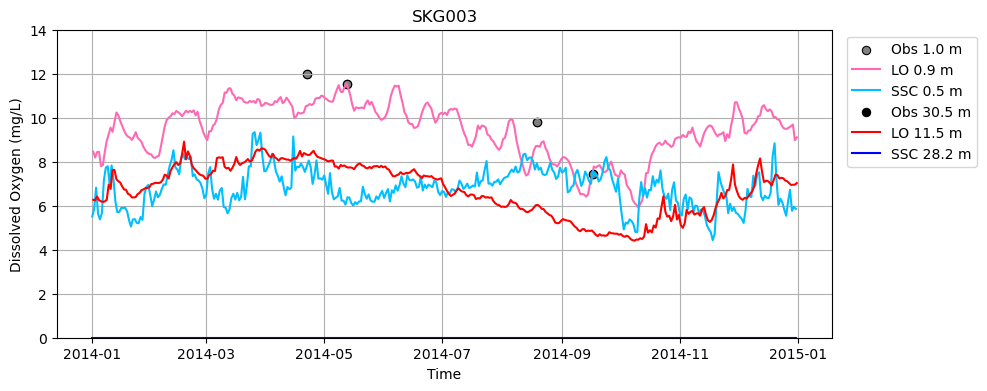

In [4]:
station = "SKG003" # "GOR001" "CSE001" "HCB004" "HCB003" "CMB003" "SIN001" "EAP001" "ADM003" "PSB003" "PSS019" "SKG003" "SAR003"

# variable to plot
varname_ssc = "dissolved_oxygen"
varname_lo = "oxygen"
varname_obs = "DO"

ds_ssc = data_ssc[station]
ds_lo = data_lo[station]
ds_obs = data_obs[data_obs["name"] == station]

surface_depth = -1.0
bottom_depth = -30.5

depth_colors = {
    -1.0: {
        "obs": "gray",
        "lo": "hotpink",
        "ssc": "deepskyblue",
    },
    -30.5: {
        "obs": "black",
        "lo": "red",
        "ssc": "blue",
    }
}

plt.figure(figsize=(10,4))

for obs_depth in [surface_depth, bottom_depth]:
    

    ds_obs_depth = ds_obs[np.isclose(ds_obs["z"], obs_depth)]

    # SSC
    ssc_depths = -ds_ssc["deptht"].values
    ssc_ind = np.argmin(np.abs(ssc_depths - obs_depth))
    ssc_model_depth = ssc_depths[ssc_ind]
    ds_ssc_depth = ds_ssc.isel(deptht=ssc_ind)

    # LO
    lo_depths = ds_lo["z_rho"].mean(dim="ocean_time").values
    lo_ind = np.argmin(np.abs(lo_depths - obs_depth))
    lo_model_depth = lo_depths[lo_ind]
    ds_lo_depth = ds_lo.isel(s_rho=lo_ind)

    plt.scatter(
        ds_obs_depth["time"],
        ds_obs_depth[varname_obs] * 0.032,
        color=depth_colors[obs_depth]["obs"],
        edgecolors="black",   
        linewidths=0.8,       
        label=f"Obs {abs(obs_depth):.1f} m"
    )

    plt.plot(
        ds_lo_depth["ocean_time"],
        ds_lo_depth[varname_lo] * 0.032,
        color=depth_colors[obs_depth]["lo"],
        label=f"LO {abs(lo_model_depth):.1f} m"
    )

    plt.plot(
        ds_ssc_depth["time_counter"],
        ds_ssc_depth[varname_ssc] * 0.032,
        color=depth_colors[obs_depth]["ssc"],
        label=f"SSC {abs(ssc_model_depth):.1f} m"
    )
    
plt.title(
f"{station}")

plt.ylim(0, 14)
plt.ylabel("Dissolved Oxygen (mg/L)")
plt.xlabel("Time")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid()
plt.show()

In [9]:
print(data_ssc)

{'SAR003': <xarray.Dataset> Size: 1MB
Dimensions:                       (time_counter: 365, deptht: 40)
Coordinates:
  * time_counter                  (time_counter) datetime64[ns] 3kB 2014-01-0...
  * deptht                        (deptht) float64 320B 0.5 1.5 ... 414.5 441.5
Data variables: (12/19)
    PAR                           (time_counter, deptht) float32 58kB ...
    turbidity                     (time_counter, deptht) float32 58kB ...
    dissolved_inorganic_carbon    (time_counter, deptht) float32 58kB ...
    total_alkalinity              (time_counter, deptht) float32 58kB ...
    dissolved_oxygen              (time_counter, deptht) float32 58kB ...
    votemper                      (time_counter, deptht) float32 58kB ...
    ...                            ...
    flagellates                   (time_counter, deptht) float32 58kB ...
    microzooplankton              (time_counter, deptht) float32 58kB ...
    dissolved_organic_nitrogen    (time_counter, deptht) float32 58

In [6]:
print(data_lo)

{'SAR003': <xarray.Dataset> Size: 844kB
Dimensions:        (s_rho: 30, ocean_time: 365, s_w: 31)
Coordinates:
    lat_rho        float64 8B ...
    lat_u          float64 8B ...
    lat_v          float64 8B ...
    lon_rho        float64 8B ...
    lon_u          float64 8B ...
    lon_v          float64 8B ...
  * ocean_time     (ocean_time) datetime64[ns] 3kB 2014-01-01T12:00:00 ... 20...
  * s_rho          (s_rho) float64 240B -0.9833 -0.95 -0.9167 ... -0.05 -0.01667
Dimensions without coordinates: s_w
Data variables: (12/24)
    Cs_r           (s_rho) float64 240B ...
    LdetritusC     (ocean_time, s_rho) float32 44kB ...
    LdetritusN     (ocean_time, s_rho) float32 44kB ...
    NH4            (ocean_time, s_rho) float32 44kB ...
    NO3            (ocean_time, s_rho) float32 44kB ...
    SdetritusC     (ocean_time, s_rho) float32 44kB ...
    ...             ...
    u              (ocean_time, s_rho) float32 44kB ...
    v              (ocean_time, s_rho) float32 44kB ...
    